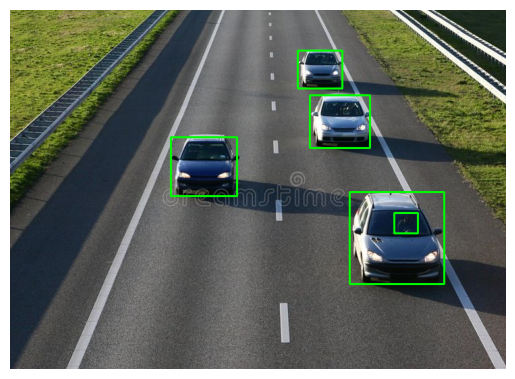

In [ ]:
import torch
import torchvision
from torchvision.transforms import functional as F
from torchvision.models.detection import FasterRCN_ResNet50_FPN_Weights
import matplotlib.pyplot as plt
import cv2

# Load model
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights)
model.eval()

# Load image
image_path = 'no.jpg'
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert to tensor (NO unsqueeze)
image_tensor = F.to_tensor(image_rgb)

# Inference
with torch.no_grad():
    predictions = model([image_tensor])

boxes = predictions[0]['boxes']
labels = predictions[0]['labels']
scores = predictions[0]['scores']

# Draw boxes
for i in range(len(boxes)):
    if scores[i] > 0.3:
        x1, y1, x2, y2 = boxes[i]
        cv2.rectangle(
            image,
            (int(x1), int(y1)),
            (int(x2), int(y2)),
            (0, 255,0),
            2
        )

# Show image
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()